In [38]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv', encoding='latin1', engine='python', on_bad_lines='skip')

In [39]:
df = orders.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['review_score'] = pd.to_numeric(df['review_score'], errors='coerce')

In [40]:
df['tempo_entrega'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

df = df[df['tempo_entrega'].notna()]
df = df[df['tempo_entrega'] > 0]
df['faixa_entrega'] = pd.cut(
    df['tempo_entrega'],
    bins=[0, 5, 10, 15, 20, 30, 100],
    labels=['0-5', '6-10', '11-15', '16-20', '21-30', '30+']
)

analise = df.groupby('faixa_entrega')['review_score'].mean()

/tmp/ipykernel_2756/4085647807.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise = df.groupby('faixa_entrega')['review_score'].mean()


In [41]:
analise = df.groupby('faixa_entrega').agg({
    'review_score': 'mean',
    'order_id': 'count'
})

analise.columns = ['nota_media', 'qtd_pedidos']

/tmp/ipykernel_2756/2154185905.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise = df.groupby('faixa_entrega').agg({


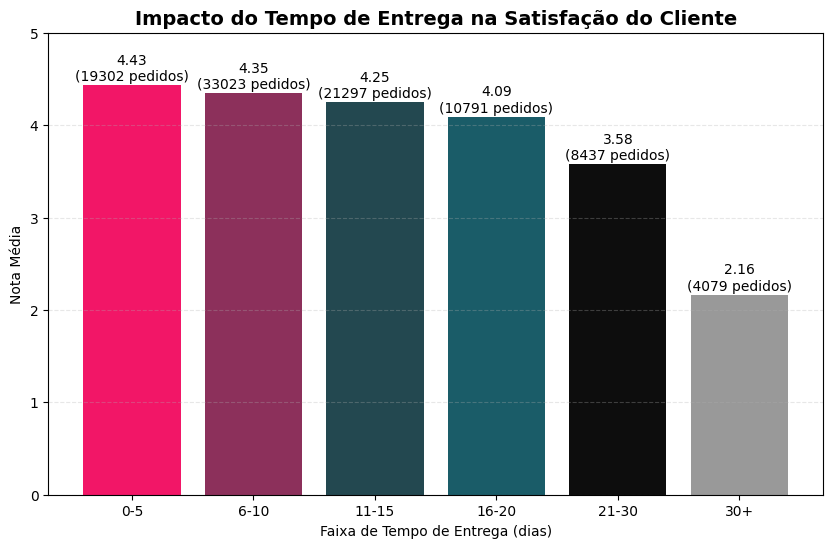

In [42]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    analise.index.astype(str),
    analise['nota_media'],
    color=cores_fiap[:len(analise)]
)

plt.title('Impacto do Tempo de Entrega na Satisfação do Cliente', fontsize=14, weight='bold')
plt.xlabel('Faixa de Tempo de Entrega (dias)')
plt.ylabel('Nota Média')

plt.ylim(0,5)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, v in enumerate(analise['nota_media']):
    qtd = analise['qtd_pedidos'].iloc[i]
    plt.text(
        i,
        v + 0.05,
        f'{v:.2f}\n({qtd} pedidos)',
        ha='center',
        color='black'
    )

plt.show()